# Marketing Landscape Report: Sleep Music, White Noise & Adjacent Wellness Audio

**Scope.** YouTube channels and mobile apps that sell (or monetize) sleep music, white noise, nature soundscapes, and closely adjacent meditation / sleep products.

**Method.** Reproducible Python collectors scrape public YouTube / vidIQ / NicheTracker pages and Apple / Google storefronts. Published third-party statistics (Business of Apps, Sensor Tower blogs, Sleep Cycle filings, Grand View Research, LensPOV) are curated into CSVs with per-row citations. Every plotted figure is traceable to a source URL.

**As-of.** Primary live scrapes: July 2026. Published annual series mostly cover 2015–2025.

> **Caveats.** YouTube “earnings” from vidIQ are model estimates, not AdSense dashboards. App MAU / revenue for private apps are estimates or US-only weekly snapshots unless a company files publicly (Sleep Cycle). Treat ranges, not point estimates, as decision-grade.


## 0. Setup & data inventory

Run collectors before this notebook (or rely on committed `data/` snapshots):

```bash
uv sync
uv run python scripts/build_curated_datasets.py
uv run python scripts/fetch_youtube_channels.py
uv run python scripts/fetch_app_store_signals.py
```


In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

ROOT = Path(".").resolve()
if not (ROOT / "data" / "processed").exists():
    ROOT = Path("researches/sleep_music_landscape").resolve()
PROC = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw"
FIG = ROOT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
})

def load(name: str) -> pd.DataFrame:
    return pd.read_csv(PROC / name)

files = sorted(p.name for p in PROC.glob("*.csv"))
print("Processed datasets:")
for f in files:
    df = load(f)
    print(f"  {f:45} {df.shape[0]:4} rows × {df.shape[1]} cols")


Processed datasets:
  app_calm_headspace_timeseries.csv               59 rows × 6 cols
  app_category_revenue_comparison.csv              5 rows × 6 cols
  app_landscape_point_estimates.csv                7 rows × 13 cols
  app_sensor_tower_wellness_q2_2024.csv           23 rows × 8 cols
  app_sleep_cycle_kpis.csv                         8 rows × 7 cols
  app_store_signals.csv                           15 rows × 17 cols
  market_size.csv                                  6 rows × 6 cols
  youtube_channel_seed_stats.csv                   5 rows × 11 cols
  youtube_channels.csv                            13 rows × 22 cols
  youtube_cpm_by_niche.csv                        10 rows × 8 cols
  youtube_videos_sample.csv                        0 rows × 9 cols


## 1. Market framing

Sleep audio sits at the intersection of **wellness apps**, **faceless YouTube ambient content**, and **consumer sleep tech**. Market-size anchors:

| Market | Year | Value | Source |
|--------|------|-------|--------|
| Spiritual wellness apps (global) | 2024 | **$2.16B** | [Grand View Research](https://www.grandviewresearch.com/industry-analysis/spiritual-wellness-apps-market-report) |
| Spiritual wellness apps (global) | 2025e | **$2.45B** | same |
| Spiritual wellness apps (global) | 2033e | **$7.31B** (CAGR 14.63% 2025–2033) | same |
| Meditation & mindfulness share | 2024 | **42.14%** of spiritual wellness (~$0.91B) | same |
| Health & Fitness app IAP (global) | 2025e | **>$4B** | [Sensor Tower H&F 2025](https://sensortower.com/blog/state-of-mobile-health-and-fitness-in-2025) |
| H&F downloads (global) | 2024 | **3.6B** installs | same |
| Sleep tech market (Sleep Cycle narrative) | ~2025 | **SEK 17B** | [Sleep Cycle Annual Report 2025](https://storage.mfn.se/d5bebf48-cfa5-4ce7-bb55-f23b91e4ea38/sleep-cycle-annual-and-sustainability-report-2025.pdf) |


<>:4: SyntaxWarning: invalid escape sequence '\('
<>:4: SyntaxWarning: invalid escape sequence '\('
/tmp/ipykernel_3900/3736597119.py:4: SyntaxWarning: invalid escape sequence '\('
  plot_m = market[market["market"].str.contains("Spiritual wellness apps \(global\)", regex=True)].copy()


,market,year,value_usd_bn,notes,source_name,source_url
0,Spiritual wellness apps (global),2024,2.16,Grand View Research market size,Grand View Research — Spiritual Wellness Apps ...,https://www.grandviewresearch.com/industry-ana...
1,Spiritual wellness apps (global),2025,2.45,projected,Grand View Research — Spiritual Wellness Apps ...,https://www.grandviewresearch.com/industry-ana...
2,Spiritual wellness apps (global),2033,7.31,projected; CAGR 14.63% 2025–2033,Grand View Research — Spiritual Wellness Apps ...,https://www.grandviewresearch.com/industry-ana...
3,Meditation & mindfulness apps share of spiritu...,2024,0.91,42.14% revenue share of spiritual wellness apps,Grand View Research — Spiritual Wellness Apps ...,https://www.grandviewresearch.com/industry-ana...
4,Health & Fitness apps global IAP revenue,2025,4.00,Sensor Tower outlook: H&F to fly past $4B glob...,Sensor Tower — State of Mobile Health & Fitnes...,https://sensortower.com/blog/state-of-mobile-h...
5,Health & Fitness apps global downloads,2024,3.60,3.6 billion downloads (value_usd_bn column reu...,Sensor Tower — State of Mobile Health & Fitnes...,https://sensortower.com/blog/state-of-mobile-h...


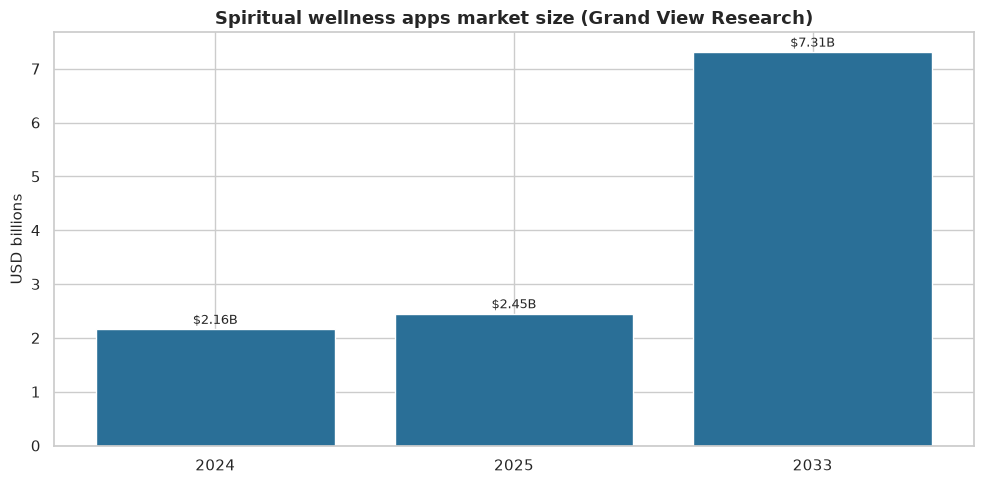

Sources:
  - Grand View Research — Spiritual Wellness Apps Market: https://www.grandviewresearch.com/industry-analysis/spiritual-wellness-apps-market-report
  - Sensor Tower — State of Mobile Health & Fitness Apps 2025: https://sensortower.com/blog/state-of-mobile-health-and-fitness-in-2025


In [2]:
market = load("market_size.csv")
display(market)

plot_m = market[market["market"].str.contains("Spiritual wellness apps \(global\)", regex=True)].copy()
fig, ax = plt.subplots()
ax.bar(plot_m["year"].astype(str), plot_m["value_usd_bn"], color="#2A6F97")
ax.set_ylabel("USD billions")
ax.set_title("Spiritual wellness apps market size (Grand View Research)")
for x, y in zip(plot_m["year"].astype(str), plot_m["value_usd_bn"]):
    ax.text(x, y + 0.1, f"${y:.2f}B", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIG / "market_spiritual_wellness.png", dpi=150)
plt.show()
print("Sources:")
for _, r in market.drop_duplicates("source_url").iterrows():
    print(f"  - {r['source_name']}: {r['source_url']}")


## 2. YouTube analysis

### 2.1 Niche economics (CPM / RPM vs other categories)

Ambient & sleep soundscapes are a **high-watch-time, mid/low-CPM** niche:

- NicheTracker (June 2026 review): CPM **$2–$6**, average **$3**, ~**900** active channels, competition **45/100**, claimed growth **+45%**. Source: [NicheTracker](https://nichetracker.live/niche/ambient-sleep-sounds).
- Creator guides cite sleep/ASMR **RPM ~$1.50–$4** (take-home per 1,000 views). Source: [Leaxor](https://leaxor.com/creators/sleep-restore).
- Cross-niche CPM audit (LensPOV 2026, n=142 disclosures): finance median CPM **$29.30** vs music **$2.40** vs ASMR **$2.00**. Source: [LensPOV](https://lenspov.com/research/youtube-cpm-by-niche-2026/).

Sleep content monetizes via **volume × session length**, not premium CPM. Overnight 8–10 hour loops inflate watch time and mid-roll inventory even when engagement (clicks, surveys) is low — a dynamic advertisers have questioned ([Shift Media](https://shiftmedia.co/advertising/youtube-ad-pricing-and-the-rise-of-sleep-inducing-content-are-advertisers-overpaying)).


,niche,cpm_low,cpm_median,cpm_high,rpm_equiv,n,source_name,source_url
0,Insurance,20.0,31.0,55.0,17.05,3.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
1,Personal Finance,18.0,29.3,50.0,16.12,7.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
2,Education / Tutorials,5.0,8.5,14.0,4.68,5.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
3,Fitness,3.0,5.5,10.0,3.03,5.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
4,Gaming,1.8,3.4,6.5,1.87,8.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
5,Music,1.2,2.4,4.5,1.32,5.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
6,ASMR,1.0,2.0,4.0,1.10,3.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
7,Kids Content (post-COPPA),0.4,0.7,1.2,0.39,6.0,LensPOV Research — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
8,Ambient & Sleep Soundscapes,2.0,3.0,6.0,1.65,NaN,NicheTracker — Ambient & Sleep Soundscapes (Ju...,https://nichetracker.live/niche/ambient-sleep-...
9,Sleep / ASMR (creator RPM guide),NaN,NaN,NaN,2.75,NaN,Leaxor — How Sleep Restore Channels Make Video...,https://leaxor.com/creators/sleep-restore


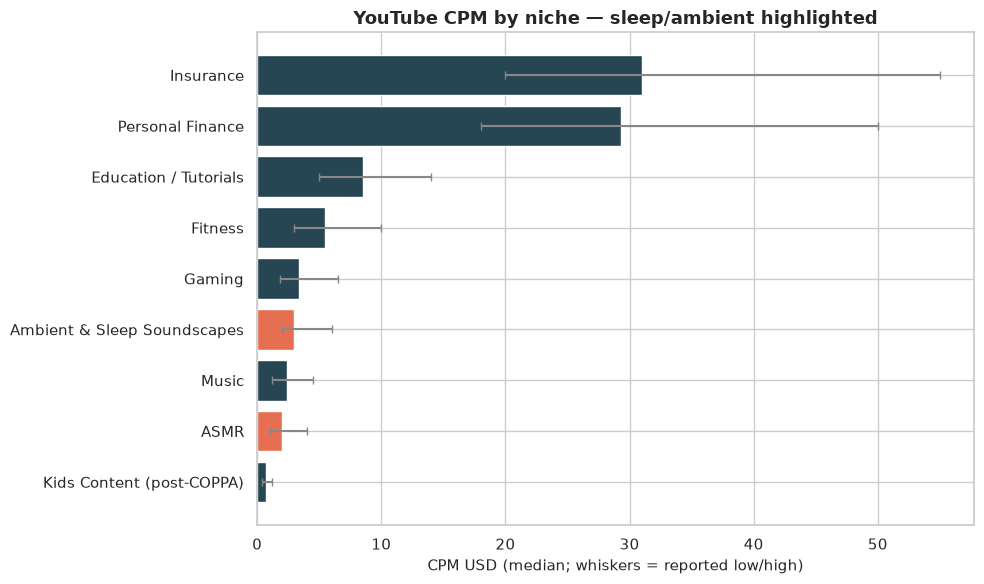

Sources:
  - LensPOV Research — YouTube CPM by Niche 2026: https://lenspov.com/research/youtube-cpm-by-niche-2026/
  - NicheTracker — Ambient & Sleep Soundscapes (June 2026 review; CPM est. from vidIQ/Miraflow): https://nichetracker.live/niche/ambient-sleep-sounds
  - Leaxor — How Sleep Restore Channels Make Videos & Earn (2026): https://leaxor.com/creators/sleep-restore


In [3]:
cpm = load("youtube_cpm_by_niche.csv")
display(cpm)

plot = cpm.dropna(subset=["cpm_median"]).sort_values("cpm_median")
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E76F51" if "Sleep" in n or "Ambient" in n or n == "ASMR" else "#264653" for n in plot["niche"]]
ax.barh(plot["niche"], plot["cpm_median"], color=colors, xerr=[
    plot["cpm_median"] - plot["cpm_low"],
    plot["cpm_high"] - plot["cpm_median"],
], error_kw={"ecolor": "#888", "capsize": 3})
ax.set_xlabel("CPM USD (median; whiskers = reported low/high)")
ax.set_title("YouTube CPM by niche — sleep/ambient highlighted")
fig.tight_layout()
fig.savefig(FIG / "youtube_cpm_by_niche.png", dpi=150)
plt.show()

print("Sources:")
for _, r in cpm.drop_duplicates("source_url").iterrows():
    print(f"  - {r['source_name']}: {r['source_url']}")


### 2.2 Channel viewership & estimated ad revenue

Live scrape of public YouTube `/about` pages + vidIQ public stats (see `scripts/fetch_youtube_channels.py`). Seed snapshots from the same sources are in `youtube_channel_seed_stats.csv` for reproducibility if a scrape fails.


In [4]:
yt = load("youtube_channels.csv")
seed = load("youtube_channel_seed_stats.csv")

# Prefer live scrape; fall back to seed for missing earnings/views
yt_f = yt.dropna(subset=["yt_subscribers"]).copy()
yt_f = yt_f[yt_f["yt_subscribers"] >= 100_000].sort_values("yt_subscribers", ascending=False)

cols = [
    "name", "handle", "category", "yt_subscribers", "yt_total_views",
    "vidiq_monthly_views", "vidiq_est_monthly_earnings_usd",
    "est_revenue_low_usd", "est_revenue_mid_usd", "est_revenue_high_usd",
    "yt_source_url", "vidiq_source_url",
]
display(yt_f[cols])

print("Implied RPM from vidIQ (est. monthly $ / monthly views × 1000):")
tmp = yt_f.dropna(subset=["vidiq_monthly_views", "vidiq_est_monthly_earnings_usd"]).copy()
tmp["implied_rpm"] = tmp["vidiq_est_monthly_earnings_usd"] / tmp["vidiq_monthly_views"] * 1000
display(tmp[["name", "vidiq_monthly_views", "vidiq_est_monthly_earnings_usd", "implied_rpm"]].sort_values("implied_rpm", ascending=False))


,name,handle,category,yt_subscribers,yt_total_views,vidiq_monthly_views,vidiq_est_monthly_earnings_usd,est_revenue_low_usd,est_revenue_mid_usd,est_revenue_high_usd,yt_source_url,vidiq_source_url
0,Soothing Relaxation,soothingrelaxation,sleep_music,12000000,5014512740,24580000,27300.00,36870.0,73740.0,98320.0,https://www.youtube.com/@soothingrelaxation/about,https://vidiq.com/youtube-stats/channel/@sooth...
1,Yellow Brick Cinema - Relaxing Music,yellowbrickcinema,sleep_music,6460000,2656109637,4710000,19300.00,7065.0,14130.0,18840.0,https://www.youtube.com/@yellowbrickcinema/about,https://vidiq.com/youtube-stats/channel/@yello...
2,Meditative Mind,meditativemind,meditation_sleep,6460000,1765621206,12350000,4170.00,18525.0,37050.0,49400.0,https://www.youtube.com/@meditativemind/about,https://vidiq.com/youtube-stats/channel/@medit...
3,Relaxing White Noise,relaxingwhitenoise,white_noise,4480000,2723683285,30300000,103150.00,45450.0,90900.0,121200.0,https://www.youtube.com/@relaxingwhitenoise/about,https://vidiq.com/youtube-stats/channel/@relax...
4,Jason Stephenson - Guided Sleep Meditation,jasonstephensonmeditation,sleep_meditation,3690000,1055567745,5580000,8070.00,8370.0,16740.0,22320.0,https://www.youtube.com/@jasonstephensonmedita...,https://vidiq.com/youtube-stats/channel/@jason...
7,Nu Meditation Music,numeditationmusic,meditation_music,3100000,946613152,8680000,4210.00,13020.0,26040.0,34720.0,https://www.youtube.com/@numeditationmusic/about,https://vidiq.com/youtube-stats/channel/@numed...
6,Michael Sealey,michaelsealey,sleep_hypnosis,2069999,457982312,2530000,7200.00,3795.0,7590.0,10120.0,https://www.youtube.com/@michaelsealey/about,https://vidiq.com/youtube-stats/channel/@micha...
8,MeditationRelaxClub,meditationrelaxclub,sleep_music,1740000,689322938,1130000,596.79,1695.0,3390.0,4520.0,https://www.youtube.com/@meditationrelaxclub/a...,https://vidiq.com/youtube-stats/channel/@medit...
9,Stardust Vibes - Relaxing Sounds,stardustvibes,ambient_sounds,1590000,434791366,1670000,6260.00,2505.0,5010.0,6680.0,https://www.youtube.com/@stardustvibes/about,https://vidiq.com/youtube-stats/channel/@stard...
10,Greenred Productions - Relaxing Music,greenredproductions,sleep_music,1320000,396459387,2490000,2010.00,3735.0,7470.0,9960.0,https://www.youtube.com/@greenredproductions/a...,https://vidiq.com/youtube-stats/channel/@green...


Implied RPM from vidIQ (est. monthly $ / monthly views × 1000):


,name,vidiq_monthly_views,vidiq_est_monthly_earnings_usd,implied_rpm
12,Headspace,1440000,5910.00,4.104167
11,Calm,3510000,14390.00,4.099715
1,Yellow Brick Cinema - Relaxing Music,4710000,19300.00,4.097665
5,The Honest Guys,850200,3410.00,4.010821
9,Stardust Vibes - Relaxing Sounds,1670000,6260.00,3.748503
3,Relaxing White Noise,30300000,103150.00,3.404290
6,Michael Sealey,2530000,7200.00,2.845850
4,Jason Stephenson - Guided Sleep Meditation,5580000,8070.00,1.446237
0,Soothing Relaxation,24580000,27300.00,1.110659
10,Greenred Productions - Relaxing Music,2490000,2010.00,0.807229


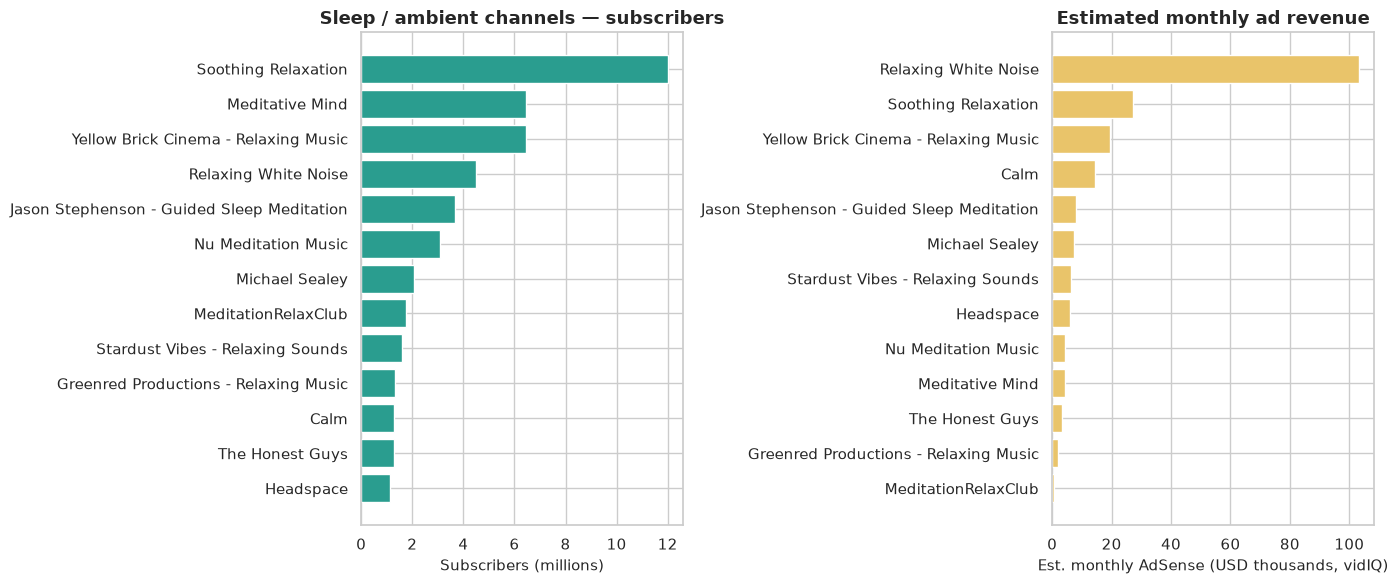

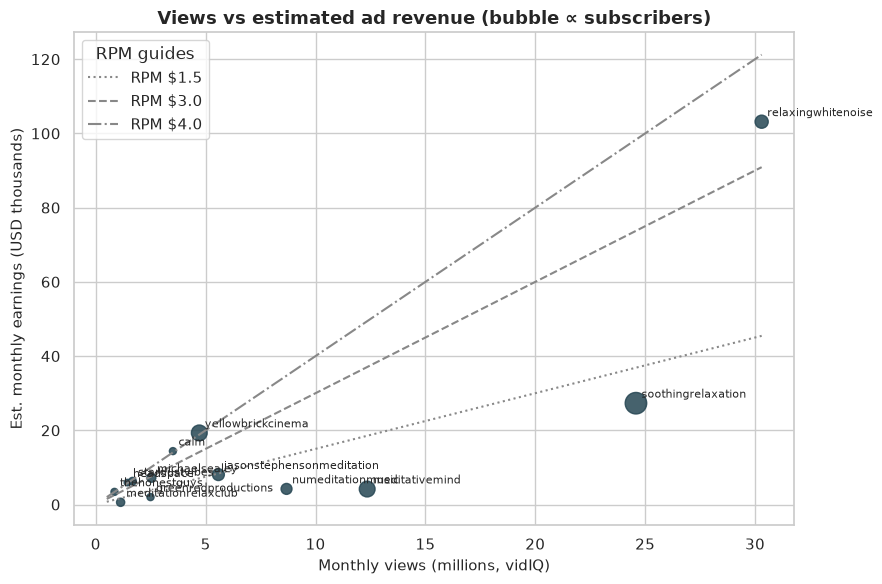

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
order = yt_f.sort_values("yt_subscribers")
ax.barh(order["name"], order["yt_subscribers"] / 1e6, color="#2A9D8F")
ax.set_xlabel("Subscribers (millions)")
ax.set_title("Sleep / ambient channels — subscribers")

ax = axes[1]
earn = yt_f.dropna(subset=["vidiq_est_monthly_earnings_usd"]).sort_values("vidiq_est_monthly_earnings_usd")
ax.barh(earn["name"], earn["vidiq_est_monthly_earnings_usd"] / 1000, color="#E9C46A")
ax.set_xlabel("Est. monthly AdSense (USD thousands, vidIQ)")
ax.set_title("Estimated monthly ad revenue")

fig.tight_layout()
fig.savefig(FIG / "youtube_subs_and_revenue.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
plot = yt_f.dropna(subset=["vidiq_monthly_views", "vidiq_est_monthly_earnings_usd"])
ax.scatter(plot["vidiq_monthly_views"] / 1e6, plot["vidiq_est_monthly_earnings_usd"] / 1000,
           s=plot["yt_subscribers"] / 50_000, c="#264653", alpha=0.85)
for _, r in plot.iterrows():
    ax.annotate(r["handle"], (r["vidiq_monthly_views"] / 1e6, r["vidiq_est_monthly_earnings_usd"] / 1000),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
# RPM guide lines
xs = np.linspace(0.5, plot["vidiq_monthly_views"].max() / 1e6, 50)
for rpm, style in [(1.5, ":"), (3.0, "--"), (4.0, "-.")]:
    ax.plot(xs, xs * rpm, style, color="#888", label=f"RPM ${rpm:.1f}")
ax.set_xlabel("Monthly views (millions, vidIQ)")
ax.set_ylabel("Est. monthly earnings (USD thousands)")
ax.set_title("Views vs estimated ad revenue (bubble ∝ subscribers)")
ax.legend(title="RPM guides")
fig.tight_layout()
fig.savefig(FIG / "youtube_views_vs_revenue.png", dpi=150)
plt.show()


,name,vidiq_est_per_video_earnings_usd,vidiq_est_monthly_earnings_usd,vidiq_source_url
0,Soothing Relaxation,9100.0,27300.00,https://vidiq.com/youtube-stats/channel/@sooth...
3,Relaxing White Noise,6070.0,103150.00,https://vidiq.com/youtube-stats/channel/@relax...
11,Calm,2880.0,14390.00,https://vidiq.com/youtube-stats/channel/@calm/
4,Jason Stephenson - Guided Sleep Meditation,2020.0,8070.00,https://vidiq.com/youtube-stats/channel/@jason...
6,Michael Sealey,1800.0,7200.00,https://vidiq.com/youtube-stats/channel/@micha...
5,The Honest Guys,1710.0,3410.00,https://vidiq.com/youtube-stats/channel/@theho...
1,Yellow Brick Cinema - Relaxing Music,1380.0,19300.00,https://vidiq.com/youtube-stats/channel/@yello...
12,Headspace,537.0,5910.00,https://vidiq.com/youtube-stats/channel/@heads...
7,Nu Meditation Music,526.0,4210.00,https://vidiq.com/youtube-stats/channel/@numed...
2,Meditative Mind,521.0,4170.00,https://vidiq.com/youtube-stats/channel/@medit...


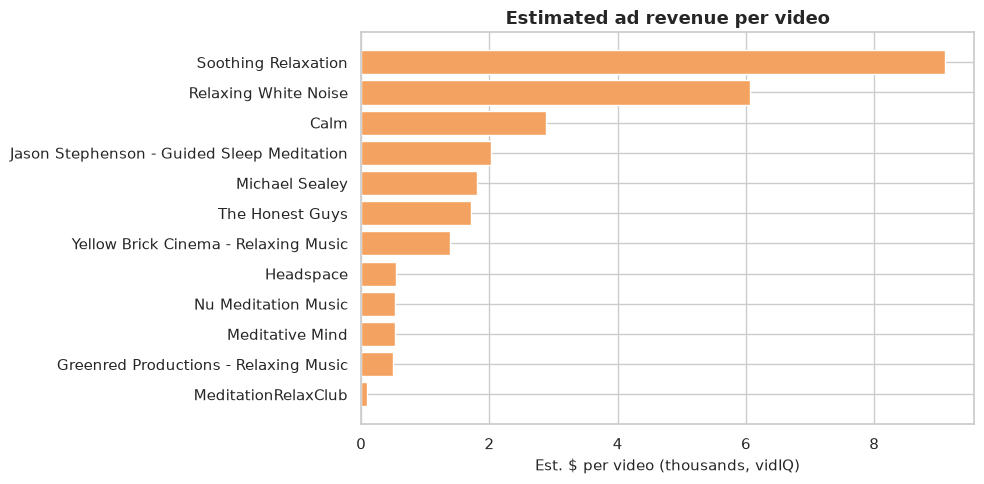

Sum of vidIQ monthly estimates across 13 channels: $205,977/mo ≈ $2,471,721/yr
Sources: YouTube about pages + https://vidiq.com/youtube-stats/channel/@<handle>/


In [6]:
# Per-video economics: monthly earnings / recent upload cadence proxy from vidIQ per-video field when present
per_vid = yt_f.dropna(subset=["vidiq_est_per_video_earnings_usd"]).sort_values(
    "vidiq_est_per_video_earnings_usd", ascending=False
)
if len(per_vid):
    display(per_vid[["name", "vidiq_est_per_video_earnings_usd", "vidiq_est_monthly_earnings_usd", "vidiq_source_url"]])
    fig, ax = plt.subplots()
    ax.barh(per_vid["name"][::-1], per_vid["vidiq_est_per_video_earnings_usd"][::-1] / 1000, color="#F4A261")
    ax.set_xlabel("Est. $ per video (thousands, vidIQ)")
    ax.set_title("Estimated ad revenue per video")
    fig.tight_layout()
    fig.savefig(FIG / "youtube_per_video_revenue.png", dpi=150)
    plt.show()
else:
    print("No per-video earnings parsed from vidIQ in this scrape.")

# Annualized ad revenue estimate for the scraped cohort
cohort = yt_f.dropna(subset=["vidiq_est_monthly_earnings_usd"])
annual = cohort["vidiq_est_monthly_earnings_usd"].sum() * 12
print(f"Sum of vidIQ monthly estimates across {len(cohort)} channels: "
      f"${cohort['vidiq_est_monthly_earnings_usd'].sum():,.0f}/mo ≈ ${annual:,.0f}/yr")
print("Sources: YouTube about pages + https://vidiq.com/youtube-stats/channel/@<handle>/")


### 2.3 YouTube takeaways vs other categories

| Dimension | Sleep / white noise / ambient | Contrast categories |
|-----------|-------------------------------|---------------------|
| CPM / RPM | Low–mid (CPM ~$2–$6; RPM ~$1.5–$4) | Finance CPM median ~$29; Education ~$8.5; Gaming ~$3.4 ([LensPOV](https://lenspov.com/research/youtube-cpm-by-niche-2026/)) |
| Watch time | Extremely high (multi-hour loops) | Typical entertainment sessions shorter |
| Faceless production | Very common; AI audio/visual rising | Face-led in finance/vlogs |
| Top-channel monthly ad est. | ~$4k–$103k in this scrape (vidIQ) | Finance channels can match with far fewer views |
| Brand upside | Mattress / wellness sponsors ([Fluxnote](https://fluxnote.io/guides/how-much-sleep-sounds-channel-makes)) | Higher CPMs already include advertiser competition |

**Notable scrape finding:** Relaxing White Noise (~4.5M subs, ~30M monthly views) shows a much higher vidIQ earnings estimate (~$103k/mo) than Soothing Relaxation (~12M subs, ~25M monthly views, ~$27k/mo). Implied RPM differs sharply — geography, ad density on long videos, and model uncertainty all matter. Always cross-check with SocialBlade / SpeakRJ ranges (SpeakRJ lists very wide bands for the same channel).


## 3. App analysis

### 3.1 Platform leaders (Calm & Headspace)

Business of Apps annual estimates (2026 editions) show pandemic-era peaks and subsequent decline in both downloads and revenue — but absolute revenue remains large versus pure white-noise utilities.


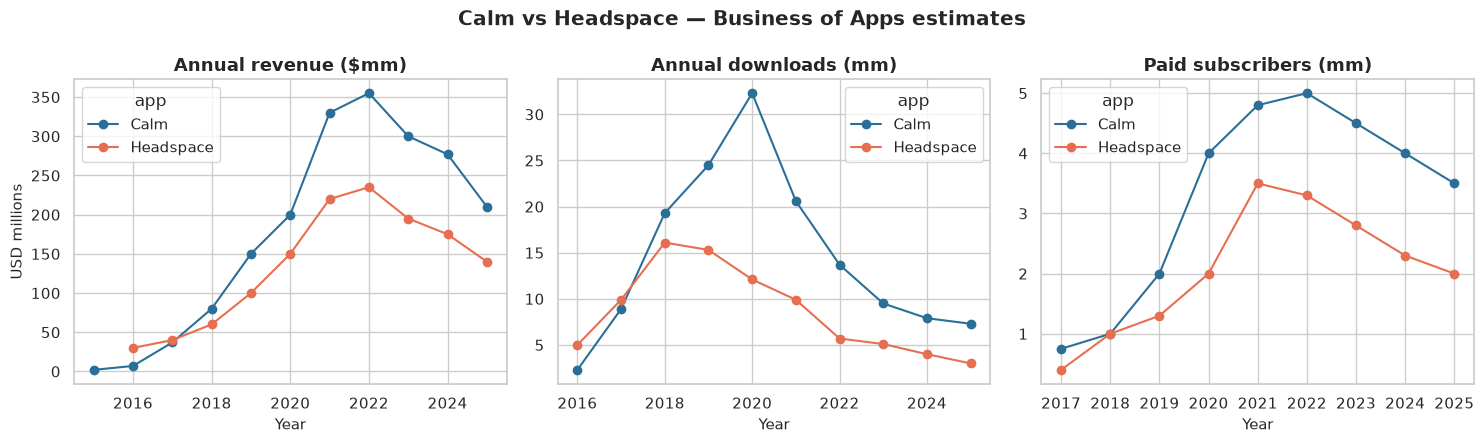

app,Calm,Headspace
year,,
2021,330.0,220.0
2022,355.0,235.0
2023,300.0,195.0
2024,277.0,175.0
2025,210.0,140.0


Sources:
  https://www.businessofapps.com/data/calm-statistics/
  https://www.businessofapps.com/data/headspace-statistics/


In [7]:
ts = load("app_calm_headspace_timeseries.csv")
rev = ts[ts["metric"] == "revenue_usd_mm"].pivot(index="year", columns="app", values="value")
dl = ts[ts["metric"] == "downloads_mm"].pivot(index="year", columns="app", values="value")
subs = ts[ts["metric"] == "paid_subscribers_mm"].pivot(index="year", columns="app", values="value")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
rev.plot(ax=axes[0], marker="o", color=["#2A6F97", "#E76F51"])
axes[0].set_title("Annual revenue ($mm)")
axes[0].set_ylabel("USD millions")
dl.plot(ax=axes[1], marker="o", color=["#2A6F97", "#E76F51"])
axes[1].set_title("Annual downloads (mm)")
subs.plot(ax=axes[2], marker="o", color=["#2A6F97", "#E76F51"])
axes[2].set_title("Paid subscribers (mm)")
for ax in axes:
    ax.set_xlabel("Year")
fig.suptitle("Calm vs Headspace — Business of Apps estimates", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG / "app_calm_headspace_trends.png", dpi=150)
plt.show()

display(rev.tail())
print("Sources:")
for u in ts["source_url"].unique():
    print(" ", u)


### 3.2 Sleep-specialist apps — downloads, active users, revenue

Mixed evidence quality:

- **Sleep Cycle** (public company): hard numbers from filings.
- **BetterSleep / ShutEye / Hatch**: US weekly downloads, revenue, WAU from Sensor Tower Q2 2024 blogs (not global MAU).
- **White Noise Deep Sleep Sounds**: third-party ML revenue models (bumetric) — low absolute $, niche utility.
- Storefront scrapes: iTunes ratings counts + Play install bands as **proxies**, not MAU.


,metric,year,value,unit,notes,source_name,source_url
0,net_sales_tsek,2025,247879.00,tSEK,Group net sales FY2025; -5.2% YoY,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
1,net_sales_tsek,2024,261529.00,tSEK,Prior-year comparison figure from YE 2025 report,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
2,paying_users,2025,768000.00,users,Paying users end-2025 (was 918k prior year),Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
3,paying_users,2024,918000.00,users,Prior-year paying users,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
4,arpu_sek,2025,277.00,SEK,Average revenue per user; currency-adjusted AR...,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
5,renewal_rate_pct,2025,45.00,percent,Subscription renewal rate stable at 45%,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
6,net_sales_usd_mm_approx,2025,23.61,USD_mm,tSEK/1000/10.5 SEK per USD illustrative conver...,Sleep Cycle Year-end Report 2025 (converted),https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
7,sleep_tech_market_sek_bn,2025,17.00,SEK_bn,Sleep tech market size cited in annual report ...,Sleep Cycle Annual and Sustainability Report 2025,https://storage.mfn.se/d5bebf48-cfa5-4ce7-bb55...


Sleep Cycle FY2025 net sales tSEK 247879.0 → ~USD 23.61 mm
Paying users 2025: 768000
Source: https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095-feedaf3fced8/sleep-cycle-year-end-report-2025.pdf


,weekly_rev_min,weekly_rev_max,weekly_dl_min,weekly_dl_max,wau_peak_or_available,illus_annual_us_rev_mid_mm
app,,,,,,
BetterSleep,166000,291000,207000,207000,917000,11.882
Hatch Sleep,239000,258000,22000,22000,963000,12.922
Headspace,428000,434000,29000,35000,550000,22.412
ShutEye,186000,377000,70000,183000,382000,14.638


Illustrative annualization = mean(weekly revenue range) × 52; US-only; NOT company-reported.
Source: https://sensortower.com/blog/2024-q2-unified-top-5-wellness%20apps-revenue-us-63e274e1e1714cfff10eaa2f


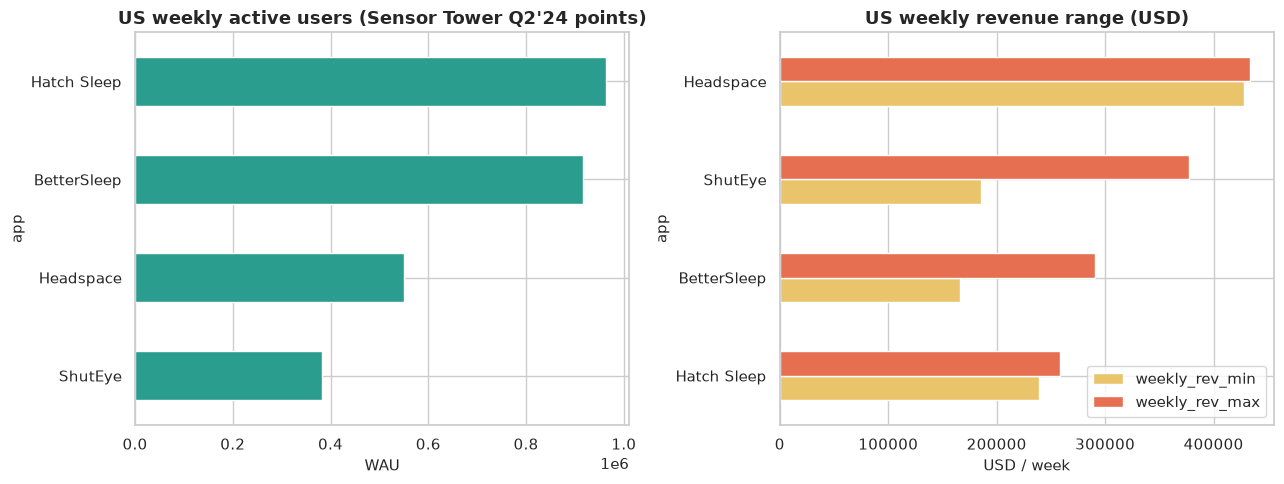

In [8]:
sc = load("app_sleep_cycle_kpis.csv")
display(sc)
print("Sleep Cycle FY2025 net sales tSEK", sc.loc[sc["metric"]=="net_sales_tsek", "value"].iloc[0],
      "→ ~USD", sc.loc[sc["metric"]=="net_sales_usd_mm_approx", "value"].iloc[0], "mm")
print("Paying users 2025:", int(sc.loc[(sc.metric=="paying_users") & (sc.year==2025), "value"].iloc[0]))
print("Source:", sc["source_url"].iloc[0])

st = load("app_sensor_tower_wellness_q2_2024.csv")
# Approximate US monthly from weekly end/start midpoint * 4.3
pivot = st.pivot_table(index="app", columns="metric", values="value", aggfunc="mean")
# Better: use available WAU / revenue points
wau = st[st["metric"]=="weekly_active_users"].groupby("app")["value"].max()
rev_w = st[st["metric"]=="weekly_revenue_usd"].groupby("app").agg(weekly_rev_min=("value","min"), weekly_rev_max=("value","max"))
dl_w = st[st["metric"]=="weekly_downloads"].groupby("app").agg(weekly_dl_min=("value","min"), weekly_dl_max=("value","max"))
summary = rev_w.join(dl_w, how="outer").join(wau.rename("wau_peak_or_available"))
summary["illus_annual_us_rev_mid_mm"] = summary[["weekly_rev_min","weekly_rev_max"]].mean(axis=1) * 52 / 1e6
display(summary)
print("Illustrative annualization = mean(weekly revenue range) × 52; US-only; NOT company-reported.")
print("Source:", st["source_url"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
summary["wau_peak_or_available"].sort_values().plot(kind="barh", ax=axes[0], color="#2A9D8F")
axes[0].set_title("US weekly active users (Sensor Tower Q2'24 points)")
axes[0].set_xlabel("WAU")
summary[["weekly_rev_min","weekly_rev_max"]].sort_values("weekly_rev_max").plot(kind="barh", ax=axes[1], color=["#E9C46A","#E76F51"])
axes[1].set_title("US weekly revenue range (USD)")
axes[1].set_xlabel("USD / week")
fig.tight_layout()
fig.savefig(FIG / "app_sensor_tower_wau_revenue.png", dpi=150)
plt.show()


,app,segment,year,downloads,mau_or_active,paid_subscribers,revenue_usd,revenue_note,source_url
0,Calm,meditation_sleep_platform,2025,7300000.0,NaN,3500000.0,210000000.0,estimated annual revenue,https://www.businessofapps.com/data/calm-stati...
1,Headspace,meditation_sleep_platform,2025,3000000.0,NaN,2000000.0,140000000.0,estimated annual revenue,https://www.businessofapps.com/data/headspace-...
2,Sleep Cycle,sleep_tracker,2025,NaN,768000.0,768000.0,23607524.0,FY2025 net sales converted at 10.5 SEK/USD,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
3,BetterSleep,sleep_sounds,2024,NaN,917000.0,NaN,NaN,US weekly revenue $166k–$291k in Q2 2024 => ro...,https://sensortower.com/blog/2024-q2-unified-t...
4,ShutEye,sleep_sounds_tracker,2024,NaN,382000.0,NaN,NaN,US weekly revenue $186k–$377k Q2 2024; AppGobl...,https://sensortower.com/blog/2024-q2-unified-t...
5,Hatch Sleep,sleep_hardware_app,2024,NaN,963000.0,NaN,NaN,US weekly revenue ~$239k–$258k Q2 2024,https://sensortower.com/blog/2024-q2-unified-t...
6,White Noise Deep Sleep Sounds,white_noise,2026,NaN,NaN,NaN,36000.0,bumetric ML estimate ~$3k/mo iOS (~$36k/yr); A...,https://bumetric.com/revenue/white-noise-deep-...


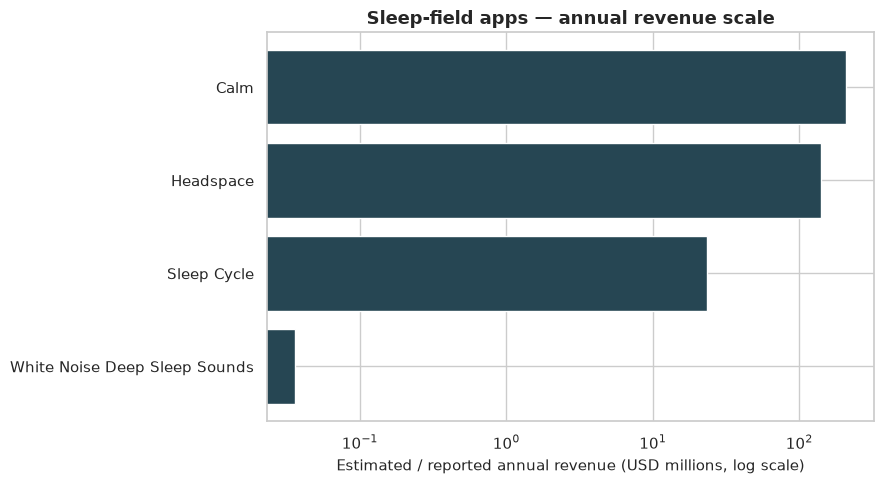

Sources:
  - Business of Apps — Calm (2026): https://www.businessofapps.com/data/calm-statistics/
  - Business of Apps — Headspace (2026): https://www.businessofapps.com/data/headspace-statistics/
  - Sleep Cycle Year-end Report 2025: https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095-feedaf3fced8/sleep-cycle-year-end-report-2025.pdf
  - Sensor Tower Q2 2024 Wellness (US unified): https://sensortower.com/blog/2024-q2-unified-top-5-wellness%20apps-revenue-us-63e274e1e1714cfff10eaa2f
  - bumetric — White Noise Deep Sleep Sounds / Slumber Studios: https://bumetric.com/revenue/white-noise-deep-sleep-sounds


In [9]:
land = load("app_landscape_point_estimates.csv")
display(land[["app","segment","year","downloads","mau_or_active","paid_subscribers","revenue_usd","revenue_note","source_url"]])

rev_plot = land.dropna(subset=["revenue_usd"]).sort_values("revenue_usd")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(rev_plot["app"], rev_plot["revenue_usd"] / 1e6, color="#264653")
ax.set_xscale("log")
ax.set_xlabel("Estimated / reported annual revenue (USD millions, log scale)")
ax.set_title("Sleep-field apps — annual revenue scale")
fig.tight_layout()
fig.savefig(FIG / "app_revenue_log.png", dpi=150)
plt.show()

print("Sources:")
for _, r in land.drop_duplicates("source_url").iterrows():
    print(f"  - {r['source_name']}: {r['source_url']}")


### 3.3 Live storefront signals (reproducible scrape)

iTunes Lookup API + Google Play HTML (`scripts/fetch_app_store_signals.py`). Install bands are Play’s public buckets (e.g. `10M+`), not exact counts. Rating volume is a rough popularity proxy.


,name,segment,ios_average_user_rating,ios_user_rating_count,play_downloads_text,play_rating_count,ios_source_url,play_source_url
0,Calm,meditation_sleep_platform,4.77325,1968646,50M+,613342.0,https://itunes.apple.com/lookup?id=571800810&c...,https://play.google.com/store/apps/details?id=...
1,Headspace,meditation_sleep_platform,4.84242,973908,10M+,339957.0,https://itunes.apple.com/lookup?id=493145008&c...,https://play.google.com/store/apps/details?id=...
2,BetterSleep,sleep_sounds,4.74272,390585,10+,NaN,https://itunes.apple.com/lookup?id=314498713&c...,https://play.google.com/store/apps/details?id=...
3,Sleep Cycle,sleep_tracker,4.67969,27305,10M+,217073.0,https://itunes.apple.com/lookup?id=320606217&c...,https://play.google.com/store/apps/details?id=...
4,ShutEye,sleep_sounds_tracker,4.76513,348852,10M+,116785.0,https://itunes.apple.com/lookup?id=1490078804&...,https://play.google.com/store/apps/details?id=...
5,White Noise Deep Sleep Sounds,white_noise,4.79615,205753,NaN,NaN,https://itunes.apple.com/lookup?id=1083248251&...,https://play.google.com/store/apps/details?id=...
6,Insight Timer,meditation,4.89499,443514,10M+,259960.0,https://itunes.apple.com/lookup?id=337472899&c...,https://play.google.com/store/apps/details?id=...
7,myNoise,noise_generator,4.71830,962,NaN,NaN,https://itunes.apple.com/lookup?id=1523675125&...,https://play.google.com/store/apps/details?id=...
8,Noisli,noise_generator,4.16863,255,NaN,NaN,https://itunes.apple.com/lookup?id=862773459&c...,https://play.google.com/store/apps/details?id=...
9,Endel,adaptive_soundscapes,4.63990,33321,1M+,21890.0,https://itunes.apple.com/lookup?id=1346247457&...,https://play.google.com/store/apps/details?id=...


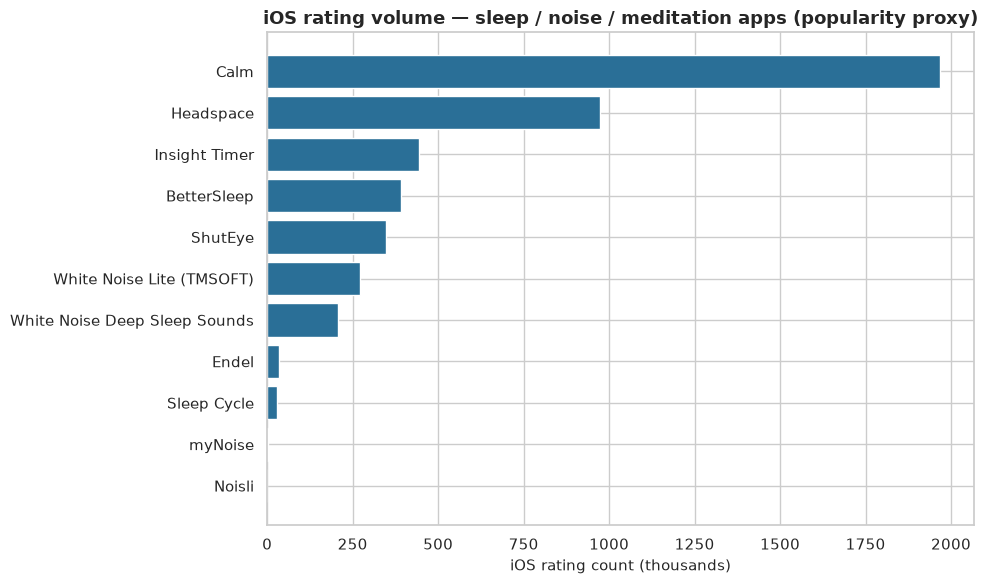

In [10]:
apps = load("app_store_signals.csv")
# Parse Play download bands to ordinal midpoints for plotting
band_map = {
    "10+": 10, "100+": 100, "1K+": 1_000, "5K+": 5_000, "10K+": 10_000,
    "50K+": 50_000, "100K+": 100_000, "500K+": 500_000,
    "1M+": 1_000_000, "5M+": 5_000_000, "10M+": 10_000_000,
    "50M+": 50_000_000, "100M+": 100_000_000, "500M+": 500_000_000, "1B+": 1_000_000_000,
}
apps["play_downloads_approx"] = apps["play_downloads_text"].map(band_map)
sleep_like = apps[apps["comparison_category"].isna()].copy()
comps = apps[apps["comparison_category"].notna()].copy()

display(sleep_like[["name","segment","ios_average_user_rating","ios_user_rating_count","play_downloads_text","play_rating_count","ios_source_url","play_source_url"]])

fig, ax = plt.subplots(figsize=(10, 6))
plot = sleep_like.dropna(subset=["ios_user_rating_count"]).sort_values("ios_user_rating_count")
ax.barh(plot["name"], plot["ios_user_rating_count"] / 1000, color="#2A6F97")
ax.set_xlabel("iOS rating count (thousands)")
ax.set_title("iOS rating volume — sleep / noise / meditation apps (popularity proxy)")
fig.tight_layout()
fig.savefig(FIG / "app_ios_ratings.png", dpi=150)
plt.show()


### 3.4 Compare sleep apps to other categories

| App / market | Category | 2025 revenue-scale | Source |
|--------------|----------|--------------------|--------|
| Calm | Sleep + meditation platform | **~$210M** | [BoA Calm](https://www.businessofapps.com/data/calm-statistics/) |
| Headspace | Meditation (+ sleep features) | **~$140M** | [BoA Headspace](https://www.businessofapps.com/data/headspace-statistics/) |
| Sleep Cycle | Sleep tracker | **~$24M** (SEK 248M) | [Sleep Cycle YE 2025](https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095-feedaf3fced8/sleep-cycle-year-end-report-2025.pdf) |
| BetterSleep / ShutEye / Hatch | Sleep sounds / tracker | US weekly **$0.17–0.43M** each in Q2'24 snapshots | [Sensor Tower](https://sensortower.com/blog/2024-q2-unified-top-5-wellness%20apps-revenue-us-63e274e1e1714cfff10eaa2f) |
| White Noise Deep Sleep Sounds | Utility white noise | **~$3k/mo** iOS model | [bumetric](https://bumetric.com/revenue/white-noise-deep-sleep-sounds) |
| Spiritual wellness apps market | Market | **~$2.45B** | Grand View Research |
| Health & Fitness IAP | Category | **>$4B** | Sensor Tower |
| Spotify / Duolingo / Strava (store signals) | Entertainment / edu / fitness | Orders-of-magnitude larger install bases (`1B+` / `500M+` / `100M+` Play bands) | Live Play scrape |


,app,category,year,revenue_usd_mm,source_name,source_url
0,Calm,sleep_meditation,2025,210.00,Business of Apps — Calm (2026),https://www.businessofapps.com/data/calm-stati...
1,Headspace,sleep_meditation,2025,140.00,Business of Apps — Headspace (2026),https://www.businessofapps.com/data/headspace-...
2,Sleep Cycle,sleep_tracker,2025,23.61,Sleep Cycle YE 2025 (SEK→USD @10.5),https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
3,Health & Fitness category IAP (global),health_fitness_category,2025,4000.00,Sensor Tower — State of Mobile H&F 2025,https://sensortower.com/blog/state-of-mobile-h...
4,Spiritual wellness apps market,spiritual_wellness_market,2025,2450.00,Grand View Research,https://www.grandviewresearch.com/industry-ana...


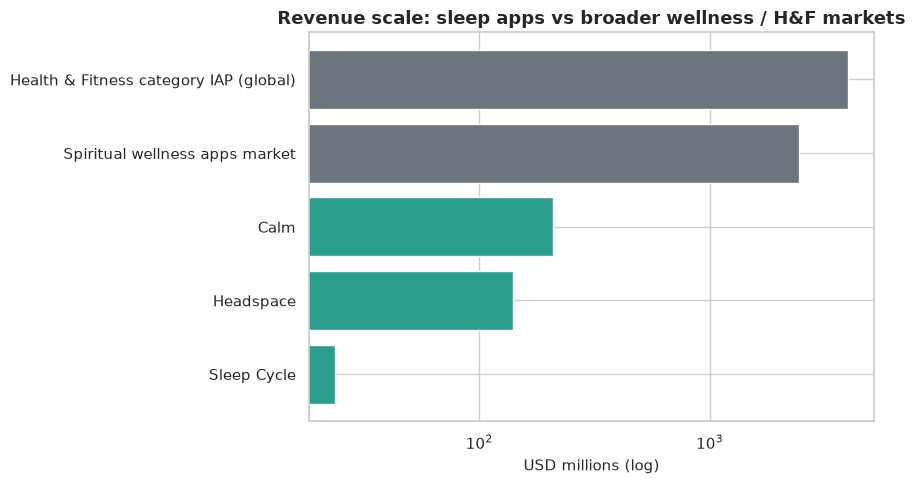

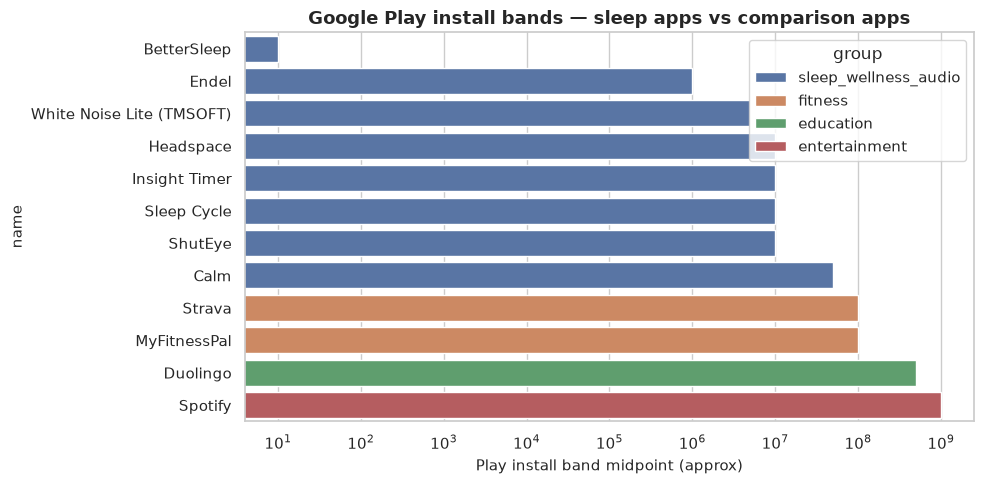

In [11]:
comp = load("app_category_revenue_comparison.csv")
display(comp)
fig, ax = plt.subplots(figsize=(9, 5))
c = comp.sort_values("revenue_usd_mm")
sleep_cats = {"sleep_meditation", "sleep_tracker"}
colors = ["#2A9D8F" if cat in sleep_cats or any(k in app for k in ("Calm", "Headspace", "Sleep")) else "#6C757D"
          for app, cat in zip(c["app"], c["category"])]
ax.barh(c["app"], c["revenue_usd_mm"], color=colors)
ax.set_xscale("log")
ax.set_xlabel("USD millions (log)")
ax.set_title("Revenue scale: sleep apps vs broader wellness / H&F markets")
fig.tight_layout()
fig.savefig(FIG / "app_category_revenue_comparison.png", dpi=150)
plt.show()

# Storefront comparison: sleep apps vs mega-categories
both = apps.dropna(subset=["play_downloads_approx"]).copy()
both["group"] = np.where(both["comparison_category"].isna(), "sleep_wellness_audio", both["comparison_category"])
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=both.sort_values("play_downloads_approx"), y="name", x="play_downloads_approx",
            hue="group", dodge=False, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Play install band midpoint (approx)")
ax.set_title("Google Play install bands — sleep apps vs comparison apps")
fig.tight_layout()
fig.savefig(FIG / "app_play_install_bands.png", dpi=150)
plt.show()


## 4. Cross-channel synthesis

1. **YouTube is the awareness / ad-supported layer.** Long-form sleep audio can generate tens of millions of monthly views per channel at low RPM; a handful of top channels likely clear **high-five to low-six figures USD / month** in ads (vidIQ models), with white-noise leaders sometimes out-earning larger “relaxing music” brands on a per-view basis.
2. **Apps are the subscription layer.** Platform brands (Calm, Headspace) still dominate revenue ($100M+), but growth cooled after 2021–22. Specialist sleep apps monetize in the **low–mid tens of millions USD** (Sleep Cycle ~$24M; US Sensor Tower run-rates for BetterSleep/ShutEye/Hatch imply meaningful but smaller businesses). Pure white-noise utilities often sit in **low thousands USD / month**.
3. **Category comparison.** Sleep audio is a meaningful slice of wellness, but small versus Health & Fitness overall ($4B+ IAP) and tiny versus entertainment mega-apps. On YouTube, sleep’s **economic engine is watch-time volume**, not CPM — structurally closer to music/ASMR than to finance/education.
4. **Data gaps.** Global MAU for BetterSleep/ShutEye/Hatch/Endel are not publicly disclosed; Sensor Tower WAU is US-only. YouTube earnings are third-party estimates. Re-run the scrapers to refresh storefront and channel stats.


## 5. Master citation index

Every statistic used above maps to one of these sources (also embedded as `source_url` columns in the CSVs):

| ID | Source | URL | What we used |
|----|--------|-----|--------------|
| S1 | Business of Apps — Calm (2026) | https://www.businessofapps.com/data/calm-statistics/ | Revenue, downloads, subscribers 2015–2025 |
| S2 | Business of Apps — Headspace (2026) | https://www.businessofapps.com/data/headspace-statistics/ | Revenue, downloads, subscribers |
| S3 | Sleep Cycle Year-end Report 2025 | https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095-feedaf3fced8/sleep-cycle-year-end-report-2025.pdf | Net sales, paying users, ARPU, renewal |
| S4 | Sleep Cycle Annual Report 2025 | https://storage.mfn.se/d5bebf48-cfa5-4ce7-bb55-f23b91e4ea38/sleep-cycle-annual-and-sustainability-report-2025.pdf | Sleep tech market SEK 17B narrative |
| S5 | Sensor Tower — State of Mobile H&F 2025 | https://sensortower.com/blog/state-of-mobile-health-and-fitness-in-2025 | H&F downloads 3.6B; IAP >$4B outlook |
| S6 | Sensor Tower — Q2 2024 Wellness US | https://sensortower.com/blog/2024-q2-unified-top-5-wellness%20apps-revenue-us-63e274e1e1714cfff10eaa2f | BetterSleep/ShutEye/Hatch/Headspace weekly rev/dl/WAU |
| S7 | Grand View Research — Spiritual Wellness Apps | https://www.grandviewresearch.com/industry-analysis/spiritual-wellness-apps-market-report | Market $2.16B→$7.31B; meditation 42.14% share |
| S8 | NicheTracker — Ambient & Sleep Soundscapes | https://nichetracker.live/niche/ambient-sleep-sounds | CPM $2–$6, channels ~900, growth +45% |
| S9 | LensPOV — YouTube CPM by Niche 2026 | https://lenspov.com/research/youtube-cpm-by-niche-2026/ | Cross-niche CPM medians |
| S10 | Leaxor — Sleep Restore channels | https://leaxor.com/creators/sleep-restore | Sleep RPM $1.50–$4; view/revenue bands |
| S11 | Fluxnote — Sleep sounds earnings | https://fluxnote.io/guides/how-much-sleep-sounds-channel-makes | RPM $2–$6; sponsor ranges |
| S12 | vidIQ public channel pages | https://vidiq.com/youtube-stats/channel/@… | Monthly views & earnings estimates |
| S13 | YouTube public `/about` pages | https://www.youtube.com/@handle/about | Subscribers, total views, country |
| S14 | SPEAKRJ — Relaxing White Noise | https://www.speakrj.com/audit/report/UCbunYN0o9Yaid7zHaor_UHA/youtube | Snapshot subs/views trajectory |
| S15 | bumetric — White Noise Deep Sleep Sounds | https://bumetric.com/revenue/white-noise-deep-sleep-sounds | ~$3k/mo iOS revenue model |
| S16 | AppGoblin — ShutEye | https://appgoblin.info/apps/1490078804 | ~1.3M MAU / $10k+ mo model (uncertain) |
| S17 | Apple iTunes Lookup API | https://itunes.apple.com/lookup?id=… | Ratings, price, metadata |
| S18 | Google Play storefront HTML | https://play.google.com/store/apps/details?id=… | Install bands, rating counts |
| S19 | Shift Media — sleep content & ad pricing | https://shiftmedia.co/advertising/youtube-ad-pricing-and-the-rise-of-sleep-inducing-content-are-advertisers-overpaying | Qualitative ad-quality critique |

Raw scrape payloads: `data/raw/youtube_channels_raw.json`, `data/raw/app_store_signals_raw.json`, `data/raw/niche_ambient_snapshot.json`.


In [12]:
# Convenience: export a citations table used by the notebook
citations = pd.DataFrame([
    {"id": f"S{i}", "source_name": n, "source_url": u}
    for i, (n, u) in enumerate([
        ("Business of Apps — Calm (2026)", "https://www.businessofapps.com/data/calm-statistics/"),
        ("Business of Apps — Headspace (2026)", "https://www.businessofapps.com/data/headspace-statistics/"),
        ("Sleep Cycle Year-end Report 2025", "https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095-feedaf3fced8/sleep-cycle-year-end-report-2025.pdf"),
        ("Sleep Cycle Annual Report 2025", "https://storage.mfn.se/d5bebf48-cfa5-4ce7-bb55-f23b91e4ea38/sleep-cycle-annual-and-sustainability-report-2025.pdf"),
        ("Sensor Tower — State of Mobile H&F 2025", "https://sensortower.com/blog/state-of-mobile-health-and-fitness-in-2025"),
        ("Sensor Tower — Q2 2024 Wellness US", "https://sensortower.com/blog/2024-q2-unified-top-5-wellness%20apps-revenue-us-63e274e1e1714cfff10eaa2f"),
        ("Grand View Research — Spiritual Wellness Apps", "https://www.grandviewresearch.com/industry-analysis/spiritual-wellness-apps-market-report"),
        ("NicheTracker — Ambient & Sleep Soundscapes", "https://nichetracker.live/niche/ambient-sleep-sounds"),
        ("LensPOV — YouTube CPM by Niche 2026", "https://lenspov.com/research/youtube-cpm-by-niche-2026/"),
        ("Leaxor — Sleep Restore channels", "https://leaxor.com/creators/sleep-restore"),
        ("vidIQ public channel stats", "https://vidiq.com/youtube-stats/"),
        ("YouTube public channel about pages", "https://www.youtube.com/"),
        ("bumetric — White Noise Deep Sleep Sounds", "https://bumetric.com/revenue/white-noise-deep-sleep-sounds"),
        ("Apple iTunes Lookup API", "https://itunes.apple.com/lookup"),
        ("Google Play storefront", "https://play.google.com/store/apps"),
    ], start=1)
])
citations.to_csv(PROC / "citations.csv", index=False)
display(citations)
print("Wrote", PROC / "citations.csv")


,id,source_name,source_url
0,S1,Business of Apps — Calm (2026),https://www.businessofapps.com/data/calm-stati...
1,S2,Business of Apps — Headspace (2026),https://www.businessofapps.com/data/headspace-...
2,S3,Sleep Cycle Year-end Report 2025,https://storage.mfn.se/79dd61f8-4ccc-4bc2-b095...
3,S4,Sleep Cycle Annual Report 2025,https://storage.mfn.se/d5bebf48-cfa5-4ce7-bb55...
4,S5,Sensor Tower — State of Mobile H&F 2025,https://sensortower.com/blog/state-of-mobile-h...
5,S6,Sensor Tower — Q2 2024 Wellness US,https://sensortower.com/blog/2024-q2-unified-t...
6,S7,Grand View Research — Spiritual Wellness Apps,https://www.grandviewresearch.com/industry-ana...
7,S8,NicheTracker — Ambient & Sleep Soundscapes,https://nichetracker.live/niche/ambient-sleep-...
8,S9,LensPOV — YouTube CPM by Niche 2026,https://lenspov.com/research/youtube-cpm-by-ni...
9,S10,Leaxor — Sleep Restore channels,https://leaxor.com/creators/sleep-restore


Wrote /workspace/researches/sleep_music_landscape/data/processed/citations.csv
